# Observables vs degree distribution

Same observables as `volatility.ipynb` (growth-rate volatility vs size, growth-rate
distribution), but the **degree distribution is a single swappable block**:
comment in *one* of regular / exponential / power-law in the config cell; everything
downstream is generic.

$\mu_c$ is found with the **shape-scalar zero-crossing** estimator. With
$c \equiv (y^*)^\top W y^* - (y^*)^\top y^*$ the rescaled mass obeys
$dM/d\tau = 1 + cM$: $M$ plateaus at $-1/c$ when $c<0$ ($\mu<\mu_c$) and grows
exponentially when $c>0$ ($\mu>\mu_c$). So $\mu_c$ is the zero-crossing of $c(\mu)$,
read off one capped integration per $\mu$ — no tanh fit, robust across degree
distributions.

In [48]:
import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import glv

In [49]:
# --- global parameters ---
N = 1000
C = 50
SIGMA = 0.2

# c-estimator integration
M_CAP = 1e250                 # halt when M reaches this (overflow ~1e308)
RTOL, ATOL, MAX_STEP = 1e-8, 1e-10, 1e3
MU_GRID = np.linspace(-2, 2, 16)   # must bracket the c(mu) zero-crossing

# observables
n_runs = 100   # realizations pooled in the multi-run section
n_bins = 25    # equal-count bins for the volatility-vs-size fit


def even(d):
    """Round to int, floor at 1, make the sum even (configuration model needs it)."""
    d = np.maximum(1, np.round(np.asarray(d))).astype(int)
    if d.sum() % 2:
        d[0] += 1
    return d

In [50]:
# =====================================================================
# DEGREE DISTRIBUTION  --  comment in EXACTLY ONE block
# make_degrees(rng) -> integer degree sequence of length N, mean ~ C
# nu_pdf(g)         -> pdf of the RESCALED degree g = k / C (mean g = 1);
#                      feeds the theoretical mu_c (None -> no theory line)
# =====================================================================

# --- regular graph: every node has degree C ------------------------
# make_degrees = lambda rng: even(np.full(N, C))
# nu_pdf = None                                # g is a delta at 1; HDMFT quad can't integrate it
# LABEL = f"regular  (k = C = {C})"

# --- exponential degree:  k ~ Exp(C)  =>  g ~ Exp(1) ---------------
# make_degrees = lambda rng: even(rng.exponential(C, N))
# nu_pdf = lambda g: np.exp(-g)
# LABEL = f"exponential  (mean k = C = {C})"

# --- power-law degree:  p(k) ~ k^-tau,  mean k = C -----------------
tau = 2.5
_kmin = C * (tau - 2) / (tau - 1)            # sets mean degree = C
make_degrees = lambda rng: even(_kmin * (1 - rng.uniform(size=N)) ** (-1 / (tau - 1)))
_gmin = (tau - 2) / (tau - 1)                # rescaled lower cutoff = _kmin / C
nu_pdf = lambda g: np.where(g >= _gmin, (tau - 1) * _gmin**(tau - 1) * g**(-tau), 0.0)
LABEL = f"power-law  (tau = {tau}, mean k = C = {C})"

print(LABEL)

power-law  (tau = 2.5, mean k = C = 50)


In [51]:
# --- graph + interaction matrix ------------------------------------
# build_graph freezes topology AND the disorder z_ij for a seed; make_W then
# dials in mu without regenerating either, so a mu-sweep stays on one realization.

def build_graph(seed):
    rng = np.random.default_rng(seed)
    degs = make_degrees(rng)
    stubs = np.repeat(np.arange(N), degs)
    rng.shuffle(stubs)
    e1, e2 = stubs[0::2], stubs[1::2]
    keep = e1 != e2                       # drop self-loops
    e1, e2 = e1[keep], e2[keep]
    rows = np.concatenate([e1, e2])
    cols = np.concatenate([e2, e1])
    A = sp.csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(N, N))
    A.data[:] = 1.0
    A = A.tolil(); A.setdiag(0); A = A.tocsr(); A.eliminate_zeros()
    coo = A.tocoo()
    z = np.random.default_rng(seed + 999).standard_normal(coo.nnz)
    return coo.row, coo.col, z


def make_W(rows, cols, z, mu):
    return sp.csr_matrix((mu / C + (SIGMA / np.sqrt(C)) * z, (rows, cols)), shape=(N, N))


# --- shape scalar c(mu) from one capped integration ----------------
def shape_c(W):
    def rhs(tau, s):
        y = np.clip(s[:N], 0.0, None); M = s[N]
        ss = y.sum()
        if ss > 0:
            y = y / ss
        F = W @ y; phi = y @ F; sq = y @ y
        dM = 0.0 if M >= M_CAP else 1.0 + M * (phi - sq)   # freeze at cap, never overflow
        return np.concatenate([y * (F - phi - y + sq), [dM], [1.0 / M]])

    s0 = np.concatenate([np.full(N, 1.0 / N), [1.0], [0.0]])
    cap = lambda tau, s: s[N] - M_CAP
    cap.terminal = True; cap.direction = 1
    sol = solve_ivp(rhs, (0.0, 1e6), s0, method="LSODA",
                    rtol=RTOL, atol=ATOL, max_step=MAX_STEP, events=cap, t_eval=[1e6])
    final = np.asarray(sol.y_events[0])[-1] if sol.t_events[0].size else sol.y[:, -1]
    y = np.clip(np.asarray(final).ravel()[:N], 0.0, None)
    y = y / y.sum()
    F = W @ y
    return float(y @ F - y @ y)


def locate_mu_c(rows, cols, z, mu_grid):
    """mu_c = first zero-crossing of c(mu), linearly interpolated on the grid."""
    cs = np.array([shape_c(make_W(rows, cols, z, mu)) for mu in mu_grid])
    sc = np.where(np.diff(np.sign(cs)))[0]
    if len(sc) == 0:
        raise RuntimeError("c(mu) never changes sign on MU_GRID — widen the grid.")
    i = sc[0]
    mu_c = mu_grid[i] - cs[i] * (mu_grid[i + 1] - mu_grid[i]) / (cs[i + 1] - cs[i])
    return mu_c, cs

<>:18: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:21: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:21: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:18: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:21: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:21: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/kj/ps34nqkd3ggg3gbs03cs8flw0000gn/T/ipykernel_26203/2184948249.

mu_c (c zero-crossing) = 0.5910    [power-law  (tau = 2.5, mean k = C = 50)]
mu_c (theoretical)     = 0.1618


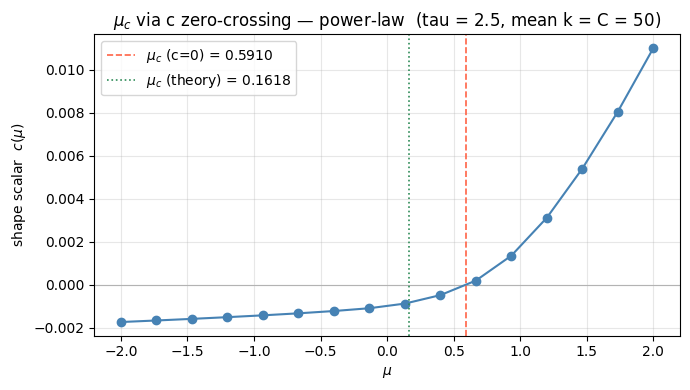

In [52]:
# --- estimate mu_c on one fixed realization ------------------------
rows, cols, z = build_graph(seed=1)
mu_c, cs = locate_mu_c(rows, cols, z, MU_GRID)
print(f"mu_c (c zero-crossing) = {mu_c:.4f}    [{LABEL}]")

# theoretical mu_c from HDMFT self-consistency (gamma=0, asymmetric weights)
mu_c_th = None
if nu_pdf is not None:
    try:
        mu_c_th = glv.calculate_mu_c(sigma=SIGMA, gamma=0.0, nu_pdf=nu_pdf)["mu_c"]
        print(f"mu_c (theoretical)     = {mu_c_th:.4f}")
    except Exception as e:
        print(f"theoretical mu_c unavailable: {e}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(MU_GRID, cs, 'o-', color='steelblue')
ax.axvline(mu_c, color='tomato', lw=1.2, ls='--', label=f'$\mu_c$ (c=0) = {mu_c:.4f}')
if mu_c_th is not None:
    ax.axvline(mu_c_th, color='seagreen', lw=1.2, ls=':', label=fr'$\mu_c$ (theory) = {mu_c_th:.4f}')
ax.set(xlabel='$\mu$', ylabel='shape scalar  $c(\mu)$', title=fr'$\mu_c$ via c zero-crossing — {LABEL}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Multi-run aggregation

Repeat the simulation `n_runs` times at fixed $\mu = \mu_c$ to accumulate statistics.
A fresh graph (degrees + disorder) and initial condition is drawn for each run.

In [53]:
Ws = []
initial_states = []
for seed in range(n_runs):
    r, c, zz = build_graph(seed)
    Ws.append(make_W(r, c, zz, mu_c))

    x0 = np.random.default_rng(seed + 10_000).uniform(0.1, 1.0, N)
    M0 = x0.sum()
    initial_states.append(np.concatenate([x0 / M0, [M0], [0.0]]))

results = glv.sweep_observables(
    Ws=Ws,
    initial_states=initial_states,
    N=N,
    tau_max=1e6,
    n_years=100,
    method='RK45',
    max_step=1e2,
    n_workers=2,
    verbose=True,
)

ok_results = [r for r in results if r is not None]
print(f'Successful runs: {len(ok_results)}/{n_runs}')

  [1/100] run 1: ok
  [2/100] run 0: ok
  [3/100] run 2: ok
  [4/100] run 3: ok
  [5/100] run 4: ok
  [6/100] run 5: ok
  [7/100] run 6: ok
  [8/100] run 7: ok
  [9/100] run 8: ok
  [10/100] run 9: ok
  [11/100] run 11: ok
  [12/100] run 10: ok
  [13/100] run 13: ok
  [14/100] run 12: ok
  [15/100] run 14: ok
  [16/100] run 15: ok
  [17/100] run 16: ok
  [18/100] run 17: ok
  [19/100] run 18: ok
  [20/100] run 19: ok
  [21/100] run 21: ok
  [22/100] run 20: ok
  [23/100] run 22: ok
  [24/100] run 23: ok
  [25/100] run 24: ok
  [26/100] run 25: ok
  [27/100] run 26: ok
  [28/100] run 27: ok
  [29/100] run 28: ok
  [30/100] run 29: ok
  [31/100] run 30: ok
  [32/100] run 31: ok
  [33/100] run 32: ok
  [34/100] run 33: ok
  [35/100] run 34: ok
  [36/100] run 35: ok
  [37/100] run 36: ok
  [38/100] run 37: ok
  [39/100] run 38: ok
  [40/100] run 39: ok
  [41/100] run 40: ok
  [42/100] run 41: ok
  [43/100] run 42: ok
  [44/100] run 43: ok
  [45/100] run 44: ok
  [46/100] run 45: ok
  [47/1

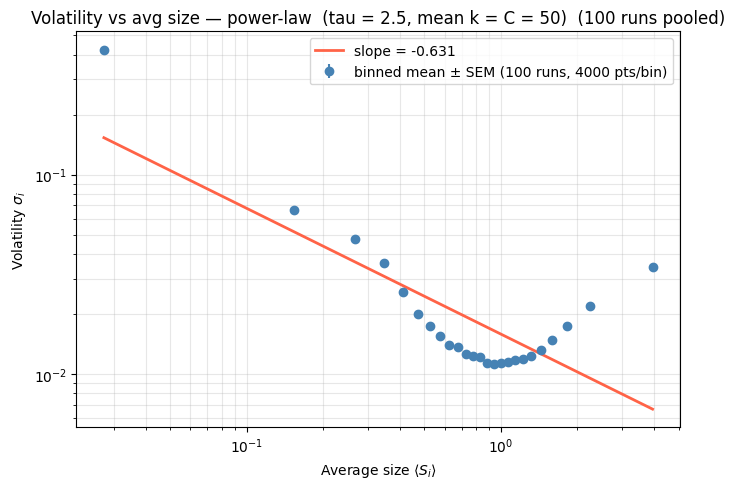

Pooled power-law slope: -0.631


In [54]:
s_all = np.concatenate([r['avg_size'] for r in ok_results])
v_all = np.concatenate([r['volatility'] for r in ok_results])

mask = (s_all > 0) & (v_all > 0) & np.isfinite(s_all) & np.isfinite(v_all)
s, v = s_all[mask], v_all[mask]

# --- equal-count bins (each bin holds the same number of points) ---
order = np.argsort(s)
s_sorted = s[order]
v_sorted = v[order]

splits = np.array_split(np.arange(s_sorted.size), n_bins)
bin_s = np.array([s_sorted[idx].mean() for idx in splits])
bin_mean = np.array([v_sorted[idx].mean() for idx in splits])
bin_sem = np.array([v_sorted[idx].std(ddof=1) / np.sqrt(idx.size) for idx in splits])
bin_n = np.array([idx.size for idx in splits])

slope, intercept = np.polyfit(np.log10(bin_s), np.log10(bin_mean), 1)
fit_x = np.logspace(np.log10(bin_s.min()), np.log10(bin_s.max()), 200)

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(bin_s, bin_mean, yerr=bin_sem, fmt='o', color='steelblue', zorder=3,
            label=f'binned mean ± SEM ({len(ok_results)} runs, {bin_n[0]} pts/bin)')
ax.plot(fit_x, 10**intercept * fit_x**slope, color='tomato', lw=2, label=f'slope = {slope:.3f}')
ax.set(xscale='log', yscale='log',
       xlabel=r'Average size $\langle S_i \rangle$',
       ylabel=r'Volatility $\sigma_i$',
       title=f'Volatility vs avg size — {LABEL}  ({len(ok_results)} runs pooled)')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()
print(f'Pooled power-law slope: {slope:.3f}')

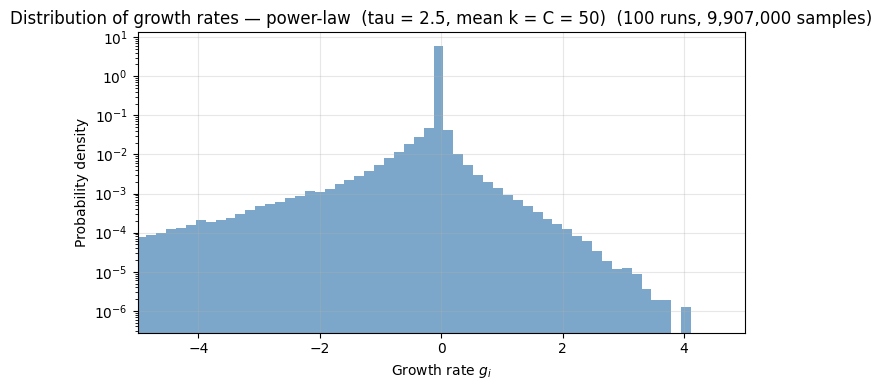

In [55]:
g_all = np.concatenate([r['g_flat'] for r in ok_results])
g_all = g_all[np.isfinite(g_all)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(g_all, bins=200, density=True, color='steelblue', alpha=0.7)
ax.set(
    xlabel='Growth rate $g_i$',
    ylabel='Probability density',
    title=f'Distribution of growth rates — {LABEL}  ({len(ok_results)} runs, {g_all.size:,} samples)',
    yscale='log',
)
ax.set_xlim(-5,5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Tail fits (GPD peaks-over-threshold)

The growth-rate tails are heavy and usually **asymmetric** (crashes vs booms).
Above a high threshold $u$, exceedances follow a Generalized Pareto distribution;
the shape $\xi$ sets tail heaviness — $\xi>0$ power-law, $\xi=0$ exponential,
$\xi<0$ bounded. Left and right tails are fit **independently** on the survival
function (CCDF), so $\xi_L$ vs $\xi_R$ quantifies the asymmetry directly.

right tail:  xi = +1.584   scale = 0.003   (u = +0.000, n = 792560)
left  tail:  xi = +1.469   scale = 0.024   (u = -0.002, n = 792560)


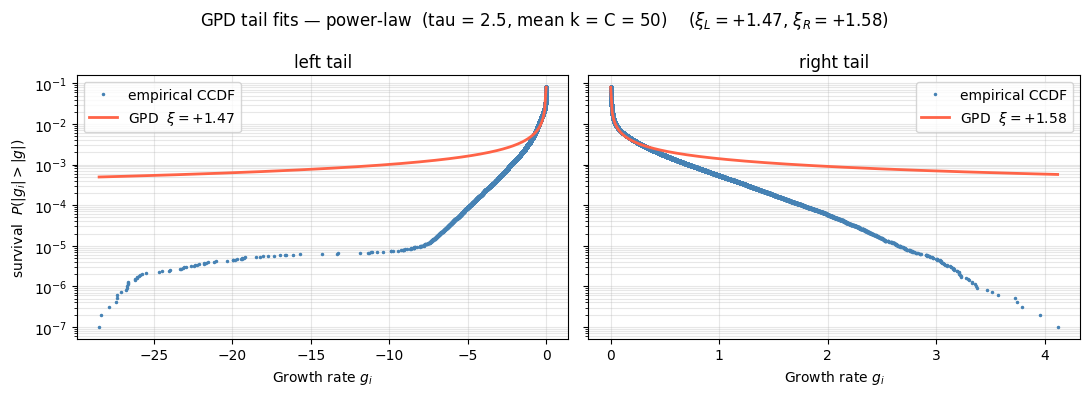

In [57]:
from scipy.stats import genpareto

# --- GPD peaks-over-threshold, left and right tails independently --
Q_TAIL = 0.92                                  # exceedance threshold quantile per tail

def fit_gpd_tail(x, u):
    """Fit GPD to exceedances of x over threshold u (location pinned at 0)."""
    exc = x[x > u] - u
    xi, _, scale = genpareto.fit(exc, floc=0.0)
    return xi, scale, exc.size / x.size, exc.size

u_R = np.quantile(g_all, Q_TAIL)
u_L = np.quantile(-g_all, Q_TAIL)              # left tail via reflection g -> -g
xi_R, sc_R, pR, nR = fit_gpd_tail(g_all, u_R)
xi_L, sc_L, pL, nL = fit_gpd_tail(-g_all, u_L)

print(f"right tail:  xi = {xi_R:+.3f}   scale = {sc_R:.3f}   (u = {u_R:+.3f}, n = {nR})")
print(f"left  tail:  xi = {xi_L:+.3f}   scale = {sc_L:.3f}   (u = {-u_L:+.3f}, n = {nL})")

# --- empirical vs GPD survival on each tail ------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, name, xp, u, xi, sc, p_exc, sign in [
    (axes[0], 'left',  -g_all, u_L, xi_L, sc_L, pL, -1),
    (axes[1], 'right',  g_all, u_R, xi_R, sc_R, pR, +1),
]:
    xs = np.sort(xp[xp > u])                                  # exceedances, ascending
    # exceedances are the top-n points: survival of xs[k] = (#points >= xs[k]) / N
    surv_emp = (xs.size - np.arange(xs.size)) / xp.size       # empirical P(|g| > x)
    grid = np.linspace(u, xs.max(), 300)
    surv_gpd = p_exc * genpareto.sf(grid - u, xi, scale=sc)
    ax.semilogy(sign * xs, surv_emp, '.', color='steelblue', ms=3, label='empirical CCDF')
    ax.semilogy(sign * grid, surv_gpd, '-', color='tomato', lw=2,
                label=fr'GPD  $\xi={xi:+.2f}$')
    ax.set(xlabel=r'Growth rate $g_i$', title=f'{name} tail')
    ax.legend()
    ax.grid(alpha=0.3, which='both')

axes[0].set_ylabel(r'survival  $P(|g_i| > |g|)$')
fig.suptitle(fr'GPD tail fits — {LABEL}    ($\xi_L={xi_L:+.2f}$, $\xi_R={xi_R:+.2f}$)')
plt.tight_layout()
plt.show()